### Data Wrangling: Analytics

In [1]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
# Load customers_enriched, products_enriched, and orders_enriched
from pathlib import Path

data_dir = Path("../data/processed")
if not data_dir.exists():
    data_dir = Path("data/processed")

customers_enriched = pd.read_csv(data_dir / "customers_enriched.csv")
products_enriched = pd.read_csv(data_dir / "products_enriched.csv")
orders_enriched = pd.read_csv(data_dir / "orders_enriched.csv")

print("Loaded:")
print("customers_enriched:", customers_enriched.shape)
print("products_enriched:", products_enriched.shape)
print("orders_enriched:", orders_enriched.shape)

Loaded:
customers_enriched: (200, 12)
products_enriched: (40, 13)
orders_enriched: (5000, 10)


In [3]:
print(customers_enriched['customer_id'].is_unique)
print(products_enriched['product_id'].is_unique)

True
True


In [4]:
# Merge customers_enriched , products_enriched and order_enriched into a single dataset
orders_master = orders_enriched.merge(customers_enriched, on="customer_id", how="left")
orders_master = orders_master.merge(products_enriched, on="product_id", how="left")

In [5]:
df = orders_master

In [6]:
# Shape
df.shape

(5000, 33)

In [7]:
# Null and duplicates check
print("Null values :",orders_master.isnull().sum())
print("Duplicate values:",orders_master.duplicated().sum())

Null values : order_id                0
customer_id             0
product_id              0
order_date              0
quantity                0
unit_price              0
discount                0
region_x                0
status                  0
revenue                 0
name                    0
age                     0
gender                  0
city                    0
region_y                0
signup_date             0
membership_tier         0
signup_year             0
tenure_days             0
age_group               0
tenure_months           0
product_name            0
category                0
cost_price              0
selling_price           0
stock_available         0
profit                  0
margin                  0
inventory_cost          0
inventory_revenue       0
inventory_risk          0
inventory_risk_label    0
price_bucket            0
dtype: int64
Duplicate values: 0


In [8]:
# Columns 
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'unit_price', 'discount', 'region_x', 'status', 'revenue', 'name',
       'age', 'gender', 'city', 'region_y', 'signup_date', 'membership_tier',
       'signup_year', 'tenure_days', 'age_group', 'tenure_months',
       'product_name', 'category', 'cost_price', 'selling_price',
       'stock_available', 'profit', 'margin', 'inventory_cost',
       'inventory_revenue', 'inventory_risk', 'inventory_risk_label',
       'price_bucket'],
      dtype='str')

In [9]:
# Save dataset
output_path = Path("data/processed/orders_master.csv")
if not output_path.parent.exists():
    output_path = Path("../data/processed/orders_master.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

#### Insights

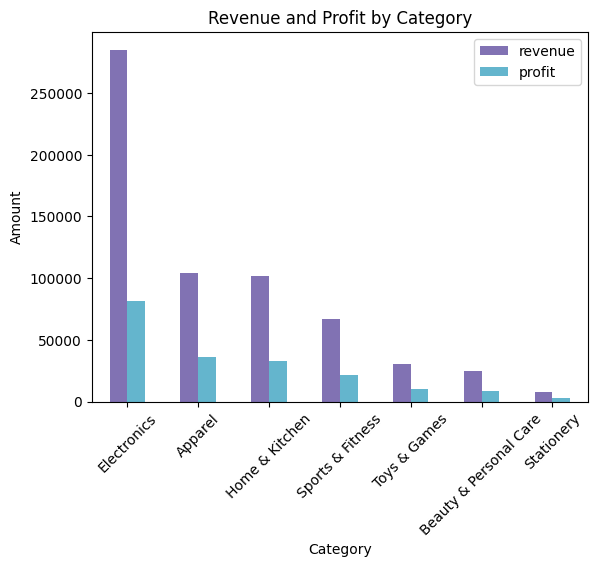

Total revenue across categories: 620,007.31
Total profit across categories: 193,513.54
Top revenue category: Electronics (285,356.54, 46.02% of total revenue)
Top profit category: Electronics (81,636.43)
Overall profit margin on revenue: 31.21%


In [10]:
# Revenue and Profit by category
cat_perf = df.groupby('category')[['revenue','profit']].sum().sort_values(by='revenue', ascending=False)

cat_perf.plot(kind='bar',color=['#8172B3','#64B5CD'])
plt.title('Revenue and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

# Numerical insights
total_revenue = cat_perf['revenue'].sum()
total_profit = cat_perf['profit'].sum()
top_revenue_cat = cat_perf['revenue'].idxmax()
top_revenue_val = cat_perf['revenue'].max()
top_profit_cat = cat_perf['profit'].idxmax()
top_profit_val = cat_perf['profit'].max()
top_revenue_share = (top_revenue_val / total_revenue) * 100 if total_revenue != 0 else 0
profit_margin_total = (total_profit / total_revenue) * 100 if total_revenue != 0 else 0

print(f"Total revenue across categories: {total_revenue:,.2f}")
print(f"Total profit across categories: {total_profit:,.2f}")
print(f"Top revenue category: {top_revenue_cat} ({top_revenue_val:,.2f}, {top_revenue_share:.2f}% of total revenue)")
print(f"Top profit category: {top_profit_cat} ({top_profit_val:,.2f})")
print(f"Overall profit margin on revenue: {profit_margin_total:.2f}%")

Electronics leads revenue ($285,356.54), while Electronics leads profit ($81,636.43).

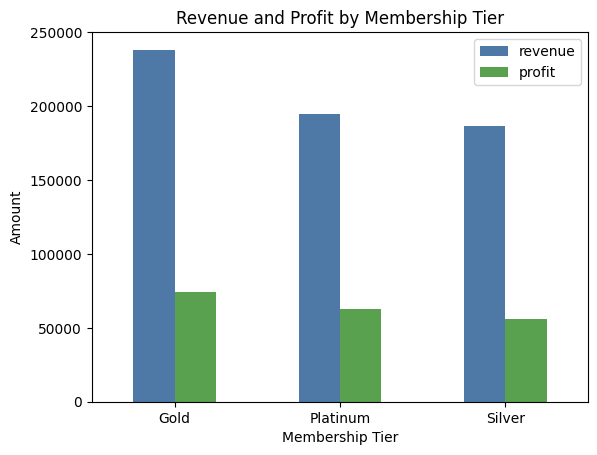

Total revenue across membership tiers: 620,007.31
Total profit across membership tiers: 193,513.54
Highest revenue tier: Gold (238,255.80, 38.43% of tier revenue)
Profit from top revenue tier: 74,595.86
Overall profit-to-revenue ratio across tiers: 31.21%


In [11]:
# Customer segment value
tier_perf = df.groupby('membership_tier')[['revenue','profit']].sum().sort_values(by='revenue', ascending=False)

tier_perf.plot(kind='bar',color=['#4E79A7','#59A14F'])
plt.title('Revenue and Profit by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

# Numerical insights
total_tier_revenue = tier_perf['revenue'].sum()
total_tier_profit = tier_perf['profit'].sum()
top_tier = tier_perf['revenue'].idxmax()
top_tier_revenue = tier_perf['revenue'].max()
top_tier_profit = tier_perf.loc[top_tier, 'profit']
top_tier_revenue_share = (top_tier_revenue / total_tier_revenue) * 100 if total_tier_revenue != 0 else 0
profit_to_revenue_ratio = (total_tier_profit / total_tier_revenue) * 100 if total_tier_revenue != 0 else 0

print(f"Total revenue across membership tiers: {total_tier_revenue:,.2f}")
print(f"Total profit across membership tiers: {total_tier_profit:,.2f}")
print(f"Highest revenue tier: {top_tier} ({top_tier_revenue:,.2f}, {top_tier_revenue_share:.2f}% of tier revenue)")
print(f"Profit from top revenue tier: {top_tier_profit:,.2f}")
print(f"Overall profit-to-revenue ratio across tiers: {profit_to_revenue_ratio:.2f}%")

The Gold membership tier makes the most money and profit compared to Platinum and Silver.

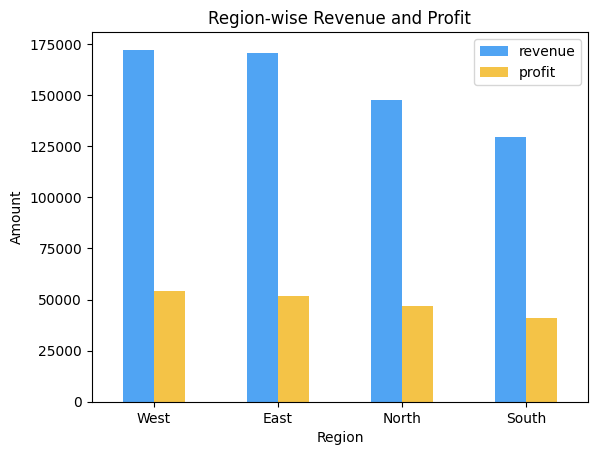

Total revenue across regions: 620,007.31
Total profit across regions: 193,513.54
Top region by revenue: West (172,181.04, 27.77% of total revenue)
Profit from top region: 53,973.13
Top region profit margin: 31.35%


In [12]:
# Region wise performance
region_perf = df.groupby('region_x')[['revenue','profit']].sum().sort_values(by='revenue', ascending=False)

region_perf.plot(kind='bar',color=["#50A4F3", "#F4C347"])
plt.title('Region-wise Revenue and Profit')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

# Numerical insights
total_region_revenue = region_perf['revenue'].sum()
total_region_profit = region_perf['profit'].sum()
top_region = region_perf['revenue'].idxmax()
top_region_revenue = region_perf['revenue'].max()
top_region_profit = region_perf.loc[top_region, 'profit']
top_region_share = (top_region_revenue / total_region_revenue) * 100 if total_region_revenue != 0 else 0
profit_margin_region = (top_region_profit / top_region_revenue) * 100 if top_region_revenue != 0 else 0

print(f"Total revenue across regions: {total_region_revenue:,.2f}")
print(f"Total profit across regions: {total_region_profit:,.2f}")
print(f"Top region by revenue: {top_region} ({top_region_revenue:,.2f}, {top_region_share:.2f}% of total revenue)")
print(f"Profit from top region: {top_region_profit:,.2f}")
print(f"Top region profit margin: {profit_margin_region:.2f}%")

The West region generates the highest revenue and profit, while the South region has the lowest in both categories.

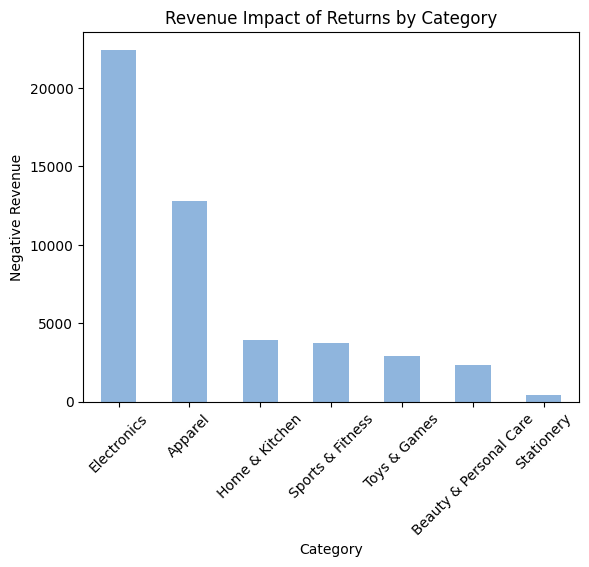

Total revenue impacted by returns: 48,606.24
Largest return loss category: Electronics (22,467.06, 46.22% of returned revenue)
Smallest return loss category: Stationery (412.08)
Return-loss gap between worst and best category: 22,054.99


In [13]:
# Return impact by category
returns = df[df['status']=='Returned'].groupby('category')['revenue'].sum().sort_values(ascending=False)

returns.plot(kind='bar',color="#8FB5DD")
plt.title('Revenue Impact of Returns by Category')
plt.xlabel('Category')
plt.ylabel('Negative Revenue')
plt.xticks(rotation=45)
plt.show()

# Numerical insights
total_returned_revenue = returns.sum()
top_return_cat = returns.idxmax()
top_return_val = returns.max()
bottom_return_cat = returns.idxmin()
bottom_return_val = returns.min()
top_return_share = (top_return_val / total_returned_revenue) * 100 if total_returned_revenue != 0 else 0
return_gap = top_return_val - bottom_return_val

print(f"Total revenue impacted by returns: {total_returned_revenue:,.2f}")
print(f"Largest return loss category: {top_return_cat} ({top_return_val:,.2f}, {top_return_share:.2f}% of returned revenue)")
print(f"Smallest return loss category: {bottom_return_cat} ({bottom_return_val:,.2f})")
print(f"Return-loss gap between worst and best category: {return_gap:,.2f}")

Electronics loses the most money from returns, while Stationery loses the least.

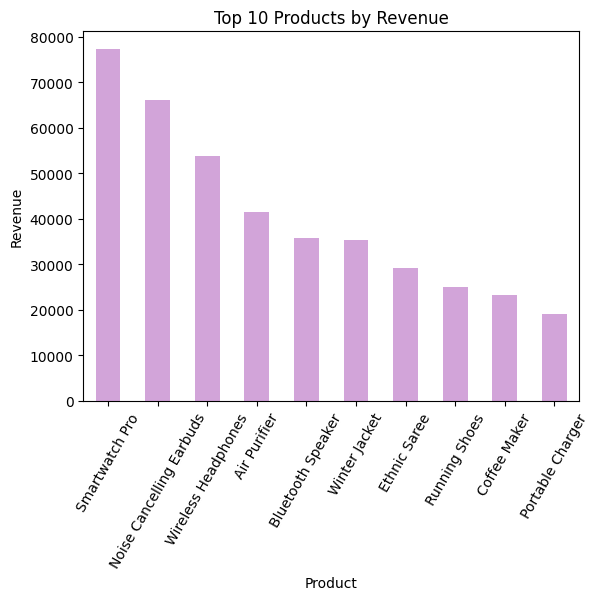

Total revenue from top 10 products: 406,123.89
Highest-revenue product: Smartwatch Pro (77,290.50, 19.03% of top-10 revenue)
Top 3 products contribute 197,170.73, or 48.55% of top-10 revenue


In [14]:
# Top products (Top 10)
top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar',color="#D2A4D9")
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=60)
plt.show()

# Numerical insights
top_product_name = top_products.idxmax()
top_product_revenue = top_products.max()
top_10_revenue = top_products.sum()
top_3_revenue = top_products.head(3).sum()
top_3_share = (top_3_revenue / top_10_revenue) * 100 if top_10_revenue != 0 else 0
top_product_share = (top_product_revenue / top_10_revenue) * 100 if top_10_revenue != 0 else 0

print(f"Total revenue from top 10 products: {top_10_revenue:,.2f}")
print(f"Highest-revenue product: {top_product_name} ({top_product_revenue:,.2f}, {top_product_share:.2f}% of top-10 revenue)")
print(f"Top 3 products contribute {top_3_revenue:,.2f}, or {top_3_share:.2f}% of top-10 revenue")

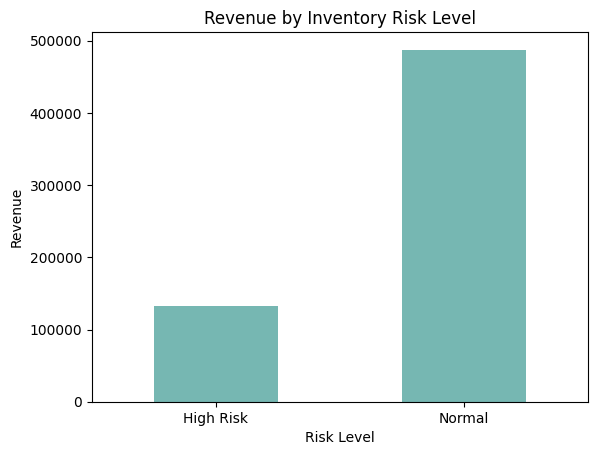

In [ ]:
# Inventory Risk vs Revenue
risk_perf = df.groupby('inventory_risk_label')['revenue'].sum().sort_values(ascending=False)

risk_perf.plot(kind='bar',color='#76B7B2')
plt.title('Revenue by Inventory Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

# Numerical insights
total_risk_revenue = risk_perf.sum()
top_risk_label = risk_perf.idxmax()
top_risk_revenue = risk_perf.max()
bottom_risk_label = risk_perf.idxmin()
bottom_risk_revenue = risk_perf.min()
top_risk_share = (top_risk_revenue / total_risk_revenue) * 100 if total_risk_revenue != 0 else 0
risk_gap = top_risk_revenue - bottom_risk_revenue

print(f"Total revenue across risk levels: {total_risk_revenue:,.2f}")
print(f"Higher-revenue risk level: {top_risk_label} ({top_risk_revenue:,.2f}, {top_risk_share:.2f}% of total)")
print(f"Lower-revenue risk level: {bottom_risk_label} ({bottom_risk_revenue:,.2f})")
print(f"Revenue gap between risk levels: {risk_gap:,.2f}")

The Normal risk level brings in much more revenue than the High Risk level.

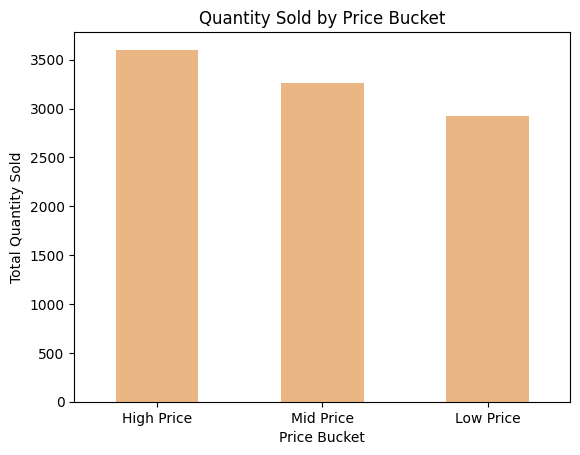

Total quantity sold across price buckets: 9,790
Highest-volume price bucket: High Price (3,602, 36.79% of total quantity)
Lowest-volume price bucket: Low Price (2,923)
Quantity gap between highest and lowest bucket: 679


In [15]:
# Price sensitivity
price_perf = df.groupby('price_bucket')['quantity'].sum().sort_values(ascending=False)

price_perf.plot(kind='bar', color="#EAB683")
plt.title('Quantity Sold by Price Bucket')
plt.xlabel('Price Bucket')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()

# Numerical insights
total_quantity = price_perf.sum()
top_price_bucket = price_perf.idxmax()
top_price_quantity = price_perf.max()
bottom_price_bucket = price_perf.idxmin()
bottom_price_quantity = price_perf.min()
top_price_share = (top_price_quantity / total_quantity) * 100 if total_quantity != 0 else 0
quantity_gap = top_price_quantity - bottom_price_quantity

print(f"Total quantity sold across price buckets: {total_quantity:,}")
print(f"Highest-volume price bucket: {top_price_bucket} ({top_price_quantity:,}, {top_price_share:.2f}% of total quantity)")
print(f"Lowest-volume price bucket: {bottom_price_bucket} ({bottom_price_quantity:,})")
print(f"Quantity gap between highest and lowest bucket: {quantity_gap:,}")

The High Price bucket has the highest number of items sold, while the Low Price bucket has the lowest.

In [16]:
# Customer lifetime value (table form)
cltv_table = (
    df.groupby('customer_id', as_index=False)['revenue']
      .sum()
      .rename(columns={'revenue': 'customer_lifetime_value'})
      .sort_values('customer_lifetime_value', ascending=False)
      .reset_index(drop=True)
)

cltv_table.head(10)

,customer_id,customer_lifetime_value
0,C1154,8715.0185
1,C1102,7814.3715
2,C1180,7347.5990
3,C1071,7312.9610
4,C1114,7072.1620
5,C1144,6272.4720
6,C1148,6154.6885
7,C1002,6131.9960
8,C1107,6023.2550
9,C1153,5990.0670
